<span><a href="https://colab.research.google.com/github/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/tp-py04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a> <a href="https://www.kaggle.com/kernels/welcome?src=https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/tp-py04.ipynb" target="_parent"><img src="https://img.shields.io/badge/Open%20in-Kaggle-20BEFF?logo=kaggle&logoColor=white" alt="Open in Kaggle"/></a> <a href="https://renkulab.io/p/fatihi.ayb/geoinformatique-ii/" target="_parent"><img src="https://renkulab.io/renku-badge.svg" alt="Launch on Renku"/></a></span>

> **Exécution dans le cloud** : ce notebook peut aussi tourner dans le cloud (Colab, Kaggle, Renku).
> Avant de lancer les cellules, télécharge les rasters (dossiers `rasters/` et `dhm25_p/`) depuis le dossier OneDrive du cours et dépose-le dans le répertoire de travail du notebook (Colab : panneau 📁 → *Upload* ; Kaggle : *File → Upload* ; Renku : déjà dans le projet).
> Procédure complète : [docs/cloud-badges.md](https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/docs/cloud-badges.md).


# TP Python 4 : Opérations raster et classification

Ce TP Python est le pendant numérique du **TP QGIS 4**. Tu vas reproduire les mêmes opérations raster en Python avec `rasterio` et `numpy`, puis entraîner des modèles de classification de l'occupation du sol (partie 7).

| Info QGIS | Attribut rasterio |
|---|---|
| Système de référence | `src.crs` |
| Dimensions | `src.height`, `src.width` |
| Emprise | `src.bounds` |
| Résolution pixel | `src.res` |
| Nombre de bandes | `src.count` |
| Valeur NoData | `src.nodata` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.plot import show
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling

from scipy.interpolate import griddata

import geopandas as gpd
import os

In [2]:
# Adapte les chemins selon l'emplacement de tes fichiers
BAND_FILES = [
    'rasters/Landsat4_1990_194028_b1.tif',
    'rasters/Landsat4_1990_194028_b2.tif',
    'rasters/Landsat4_1990_194028_b3.tif',
    'rasters/Landsat4_1990_194028_b4.tif',
    'rasters/Landsat4_1990_194028_b5.tif',
    'rasters/Landsat4_1990_194028_b6.tif',
    'rasters/Landsat4_1990_194028_b7.tif',
]
LANDCOVER_FILE = 'rasters/MapTicino1990_8classes.tif'
MNT_FILE       = 'rasters/MNT25_Ticino.tif'

# Lecture des métadonnées de la bande 4 (proche infrarouge)
with rasterio.open(BAND_FILES[3]) as src:   # index 3 = bande 4
    print("=== Métadonnées — Bande 4 (NIR) ===")
    print(f"CRS          : {src.crs}")
    print(f"Dimensions   : {src.height} lignes × {src.width} colonnes")
    print(f"Résolution   : {src.res[0]:.1f} m × {src.res[1]:.1f} m")
    print(f"Emprise      : {src.bounds}")
    print(f"Type données : {src.dtypes[0]}")
    print(f"NoData       : {src.nodata}")
    meta_ref = src.meta.copy()   # métadonnées de référence pour les sorties


=== Métadonnées — Bande 4 (NIR) ===
CRS          : EPSG:32632
Dimensions   : 7292 lignes × 8212 colonnes
Résolution   : 31.1 m × 31.3 m
Emprise      : BoundingBox(left=366798.8360244284, bottom=4983476.32585051, right=621856.6517301749, top=5212035.991148069)
Type données : uint8
NoData       : None


### 1.2 Fusion des bandes séparées en image multibandes

Dans QGIS tu utilisais *Raster > Miscellaneous > Merge* avec l'option
*"Place each input file in a separate band"*.
En Python : on empile les tableaux NumPy des 7 bandes avec `np.stack()`
et on écrit le résultat dans un GeoTIFF à 7 bandes.


In [3]:
# Lecture des 7 bandes et empilement
bands = []
for path in BAND_FILES:
    with rasterio.open(path) as src:
        bands.append(src.read(1).astype(np.float32))

landsat = np.stack(bands)   # shape : (7, height, width)
print(f"Image multibandes : {landsat.shape}")
print(f"  7 bandes × {landsat.shape[1]} lignes × {landsat.shape[2]} colonnes")

# Sauvegarde GeoTIFF multibandes (équivalent du Merge QGIS)
os.makedirs('rasters/output', exist_ok=True)
meta_multi = meta_ref.copy()
meta_multi.update({'count': 7, 'dtype': 'float32'})

with rasterio.open('rasters/output/Landsat4_1990_multibande.tif', 'w', **meta_multi) as dst:
    dst.write(landsat)

print("\nGeoTIFF multibandes sauvegardé : rasters/output/Landsat4_1990_multibande.tif")


Image multibandes : (7, 7292, 8212)
  7 bandes × 7292 lignes × 8212 colonnes



GeoTIFF multibandes sauvegardé : rasters/output/Landsat4_1990_multibande.tif


---
## Partie 2 — Compositions colorées

Dans QGIS tu choisissais les bandes R/G/B dans la symbologie.
En Python : on sélectionne les indices des bandes, on les normalise et on les empile.

| Composition | Bande R | Bande G | Bande B | Usage |
|---|---|---|---|---|
| Vraies couleurs | B3 | B2 | B1 | Vision naturelle |
| Fausses couleurs (végétation) | B4 | B3 | B2 | Végétation en rouge vif |
| Agriculture | B5 | B4 | B1 | Cultures, humidité |


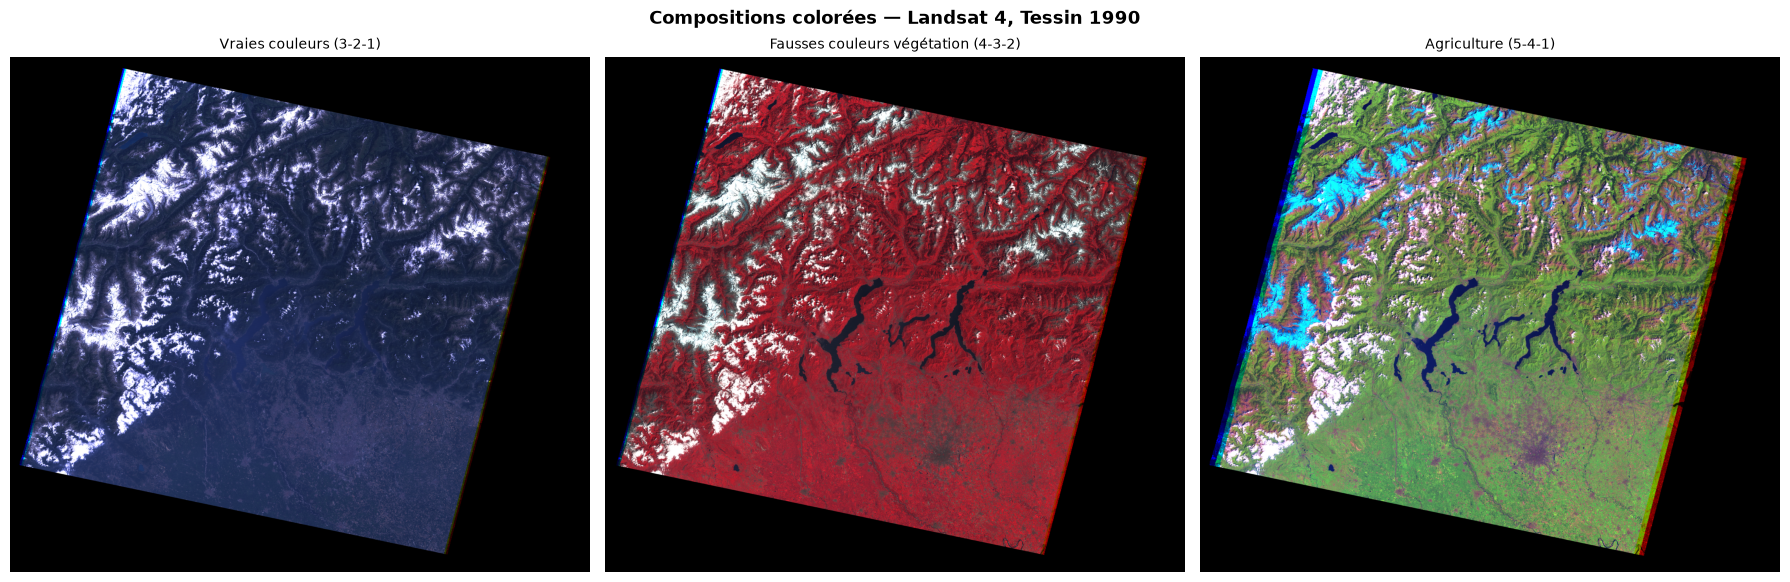

In [4]:
def normalize_band(arr, pmin=2, pmax=98):
    """Étirement de contraste : coupe les percentiles extrêmes et normalise en [0, 1]."""
    lo, hi = np.nanpercentile(arr, [pmin, pmax])
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)

def make_rgb(r_idx, g_idx, b_idx):
    """Construit une image RGB normalisée depuis les indices de bandes (1-based)."""
    r = normalize_band(landsat[r_idx - 1])
    g = normalize_band(landsat[g_idx - 1])
    b = normalize_band(landsat[b_idx - 1])
    return np.dstack([r, g, b])

compositions = [
    ('Vraies couleurs (3-2-1)',             3, 2, 1),
    ('Fausses couleurs végétation (4-3-2)', 4, 3, 2),
    ('Agriculture (5-4-1)',                 5, 4, 1),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, r, g, b) in zip(axes, compositions):
    ax.imshow(make_rgb(r, g, b), origin='upper')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('Compositions colorées — Landsat 4, Tessin 1990',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Calcul du NDVI

Le **NDVI** est calculé depuis la *Calculatrice raster* dans QGIS.
En Python : opération pixel-à-pixel NumPy sur les bandes B3 et B4.

$$\text{NDVI} = \frac{\text{NIR} - \text{Rouge}}{{\text{NIR} + \text{Rouge}}} = \frac{B4 - B3}{B4 + B3}$$

| Plage NDVI | Interprétation |
|---|---|
| -1 à 0 | Eau, neige, surfaces imperméables |
| 0 à 0.3 | Sol nu, rochers |
| 0.3 à 1 | Végétation dense (forêt, prairies) |


NDVI — min=-1.000, max=1.000, moy=0.357


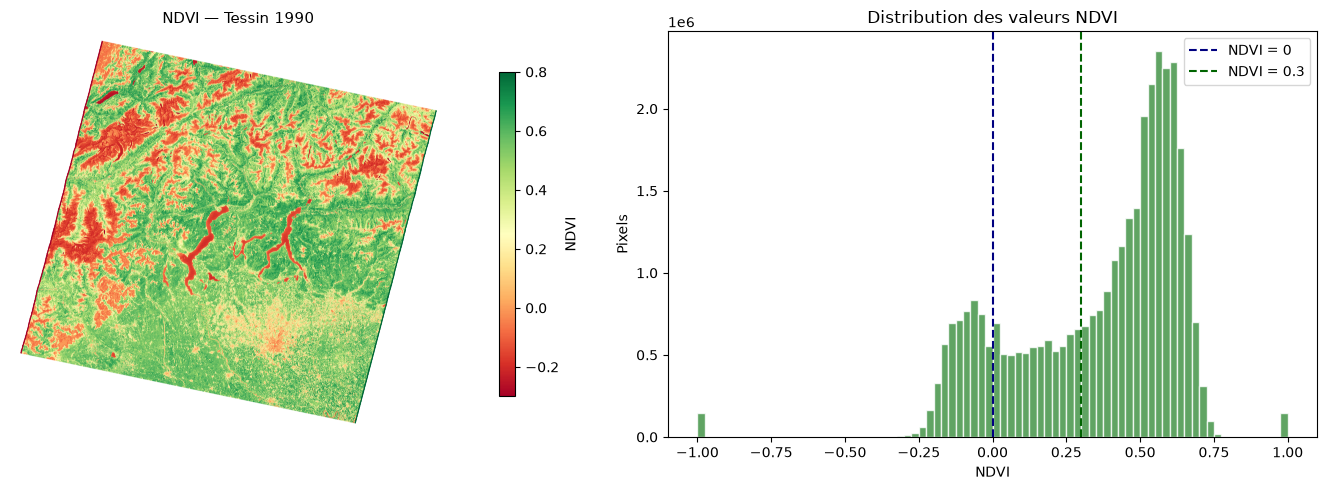

NDVI sauvegardé : rasters/output/NDVI_Ticino1990.tif


In [5]:
rouge = landsat[2].astype(np.float32)   # B3 = Rouge
nir   = landsat[3].astype(np.float32)   # B4 = NIR

with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = np.where(
        (nir + rouge) == 0,
        np.nan,
        (nir - rouge) / (nir + rouge)
    )

print(f"NDVI — min={np.nanmin(ndvi):.3f}, max={np.nanmax(ndvi):.3f}, "
      f"moy={np.nanmean(ndvi):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.3, vmax=0.8, origin='upper')
plt.colorbar(im, ax=axes[0], label='NDVI', shrink=0.8)
axes[0].set_title('NDVI — Tessin 1990', fontsize=11)
axes[0].axis('off')

axes[1].hist(ndvi[~np.isnan(ndvi)].ravel(), bins=80,
             color='#388e3c', alpha=0.8, edgecolor='white')
axes[1].axvline(0,   color='navy',      linestyle='--', label='NDVI = 0')
axes[1].axvline(0.3, color='darkgreen', linestyle='--', label='NDVI = 0.3')
axes[1].set_xlabel('NDVI')
axes[1].set_ylabel('Pixels')
axes[1].set_title('Distribution des valeurs NDVI')
axes[1].legend()

plt.tight_layout()
plt.show()

# Sauvegarde
meta_ndvi = meta_ref.copy()
meta_ndvi.update({'dtype': 'float32', 'count': 1})
with rasterio.open('rasters/output/NDVI_Ticino1990.tif', 'w', **meta_ndvi) as dst:
    dst.write(ndvi.astype(np.float32), 1)
print("NDVI sauvegardé : rasters/output/NDVI_Ticino1990.tif")


---
## Partie 4 — Reclassification de l'occupation du sol

### 4.1 Chargement et visualisation

Le fichier `MapTicino1990_8classes.tif` contient 8 classes :

| Valeur | Classe |
|---|---|
| 1 | Forêt |
| 2 | Prés |
| 3 | Eau |
| 4 | Neige |
| 5 | Sols nus |
| 6 | Aires urbaines |
| 7 | Nuages |
| 8 | Ombres |


Occupation du sol : (3456, 2707)
MNT reprojeté     : (3456, 2707)  (même grille que l'occupation du sol)

Distribution des classes (avant reclassification) :
  Classe 1 (Forêt          ) :  4200598 pixels  (44.9 %)
  Classe 2 (Prés           ) :  1513422 pixels  (16.2 %)
  Classe 3 (Eau            ) :   470355 pixels  (5.0 %)
  Classe 4 (Neige          ) :   159060 pixels  (1.7 %)
  Classe 5 (Sols nus       ) :  1458456 pixels  (15.6 %)
  Classe 6 (Aires urbaines ) :   320292 pixels  (3.4 %)
  Classe 7 (Nuages         ) :   380119 pixels  (4.1 %)
  Classe 8 (Ombres         ) :   126523 pixels  (1.4 %)


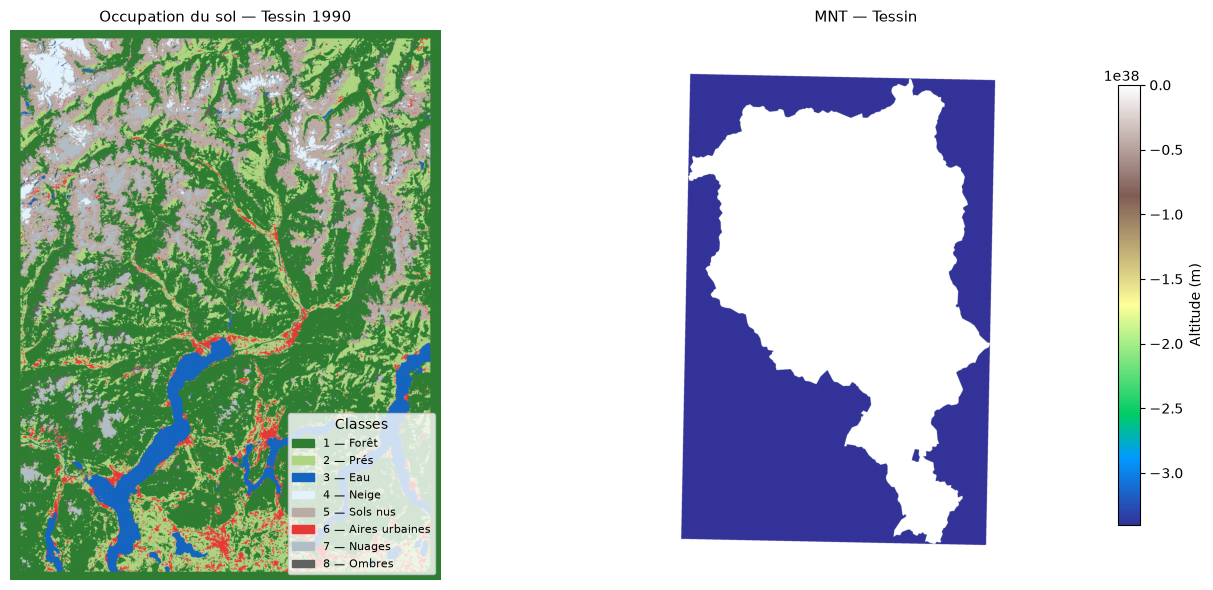

In [6]:
with rasterio.open(LANDCOVER_FILE) as src:
    landcover = src.read(1)
    meta_lc   = src.meta.copy()

# Le MNT est en EPSG:21781 (LV03) ; on le reprojette sur la grille de la carte d'occupation du sol
with rasterio.open(MNT_FILE) as src_mnt:
    mnt = np.empty((meta_lc['height'], meta_lc['width']), dtype=np.float32)
    reproject(
        source=src_mnt.read(1).astype(np.float32),
        destination=mnt,
        src_transform=src_mnt.transform,
        src_crs=src_mnt.crs,
        dst_transform=meta_lc['transform'],
        dst_crs=meta_lc['crs'],
        resampling=Resampling.bilinear,
    )

print(f"Occupation du sol : {landcover.shape}")
print(f"MNT reprojeté     : {mnt.shape}  (même grille que l'occupation du sol)")

CLASSES = {1: 'Forêt', 2: 'Prés', 3: 'Eau', 4: 'Neige',
           5: 'Sols nus', 6: 'Aires urbaines', 7: 'Nuages', 8: 'Ombres'}
COLORS  = ['#2e7d32', '#aed581', '#1565c0', '#e3f2fd',
           '#bcaaa4', '#e53935', '#b0bec5', '#616161']

print("\nDistribution des classes (avant reclassification) :")
n_total = landcover.size
for val, nom in CLASSES.items():
    n = (landcover == val).sum()
    print(f"  Classe {val} ({nom:15s}) : {n:8d} pixels  ({100*n/n_total:.1f} %)")

cmap_lc = mcolors.ListedColormap(COLORS)
norm_lc = mcolors.BoundaryNorm(range(1, 10), cmap_lc.N)
patches = [Patch(color=COLORS[i], label=f"{i+1} — {CLASSES[i+1]}") for i in range(8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(landcover, cmap=cmap_lc, norm=norm_lc, origin='upper')
axes[0].legend(handles=patches, loc='lower right', fontsize=8, title='Classes')
axes[0].set_title('Occupation du sol — Tessin 1990', fontsize=11)
axes[0].axis('off')

im = axes[1].imshow(mnt, cmap='terrain', origin='upper')
plt.colorbar(im, ax=axes[1], label='Altitude (m)', shrink=0.8)
axes[1].set_title('MNT — Tessin', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Partie 5 — Interpolation IDW

L'interpolation **IDW** prédit la valeur en tout point depuis des mesures ponctuelles.
Dans QGIS : outil IDW sur les points DHM25 de Swisstopo (résolution 900 m).
En Python : `scipy.interpolate.griddata`.

$$\hat{z}(x) = \frac{\sum_i z_i \cdot d_i^{-p}}{\sum_i d_i^{-p}}$$


In [7]:
DHM25_PATH = 'dhm25_p/dhm25_p.shp'

pts = gpd.read_file(DHM25_PATH)
print(f"Points chargés : {len(pts)}")
print(f"Colonnes       : {pts.columns.tolist()}")
print(f"CRS            : {pts.crs}")
print(pts.head(3))

Points chargés : 209505
Colonnes       : ['OBJECTID', 'OBJECTVAL', 'OBJECTORIG', 'YEAROFCHAN', 'geometry']
CRS            : EPSG:21781
   OBJECTID   OBJECTVAL OBJECTORIG  YEAROFCHAN  \
0   8561055  Hoehenkote       LK25        1987   
1   8561059  Hoehenkote       LK25        1987   
2   8561134  Hoehenkote       LK25        1981   

                          geometry  
0  POINT Z (559145.3 242445.3 715)  
1  POINT Z (560184.4 242995.3 725)  
2  POINT Z (579737.5 253873.4 523)  


MNT interpolé : (254, 428)  —  résolution 900 m
Altitude : min=-128 m, max=4515 m


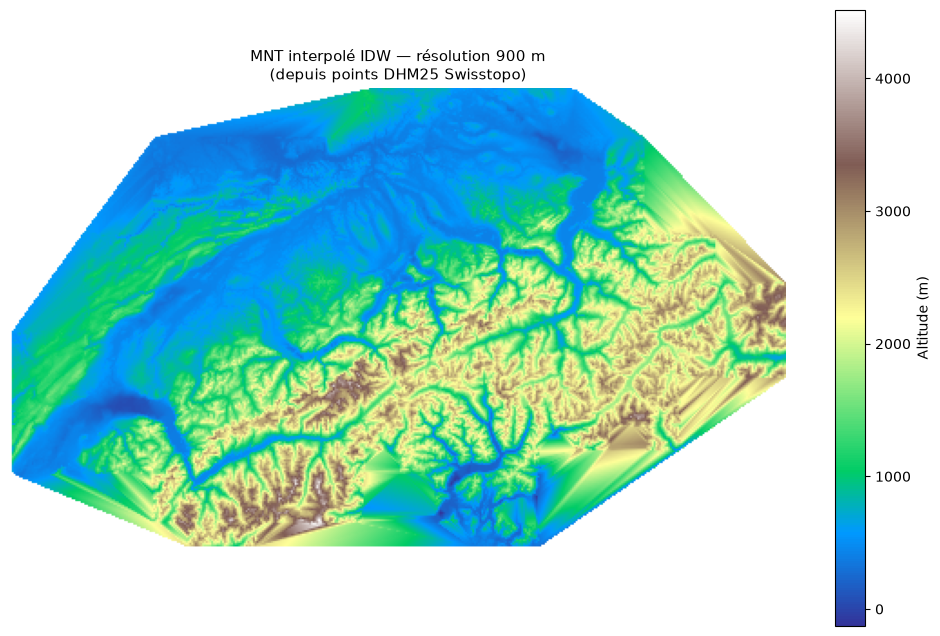

MNT IDW sauvegardé : rasters/output/MNT_IDW_900m.tif


In [8]:
# L'altitude est encodée dans la coordonnée Z de la géométrie POINT Z
xy_pts = np.column_stack([pts.geometry.x, pts.geometry.y])
z_pts  = pts.geometry.z.values

# Grille cible (résolution 900 m)
RES = 900
bounds = pts.total_bounds   # [xmin, ymin, xmax, ymax]
xi = np.arange(bounds[0], bounds[2], RES)
yi = np.arange(bounds[1], bounds[3], RES)
XX, YY = np.meshgrid(xi, yi)

# Interpolation linéaire (équivalent IDW local)
mnt_idw = griddata(xy_pts, z_pts, (XX, YY), method='linear')
mnt_idw = np.flipud(mnt_idw)   # convention raster : ligne 0 en haut

print(f"MNT interpolé : {mnt_idw.shape}  —  résolution {RES} m")
print(f"Altitude : min={np.nanmin(mnt_idw):.0f} m, max={np.nanmax(mnt_idw):.0f} m")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mnt_idw, cmap='terrain', origin='upper')
plt.colorbar(im, ax=ax, label='Altitude (m)', shrink=0.8)
ax.set_title(f'MNT interpolé IDW — résolution {RES} m\n(depuis points DHM25 Swisstopo)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

# Sauvegarde
idw_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3],
                             mnt_idw.shape[1], mnt_idw.shape[0])
with rasterio.open(
    'rasters/output/MNT_IDW_900m.tif', 'w',
    driver='GTiff', height=mnt_idw.shape[0], width=mnt_idw.shape[1],
    count=1, dtype='float32', crs=pts.crs, transform=idw_transform,
) as dst:
    dst.write(mnt_idw.astype(np.float32), 1)
print("MNT IDW sauvegardé : rasters/output/MNT_IDW_900m.tif")

---
## Partie 6 — Ombrage (Hillshade)

Dans QGIS : *Raster > Analysis > Ombrage* (azimut 315°, élévation 45°).
En Python : on calcule le gradient du MNT, puis la pente, l'exposition et le
produit scalaire avec la direction solaire.

$$\text{Hillshade} = \cos(z_s)\cos(\text{slope}) + \sin(z_s)\sin(\text{slope})\cos(a_s - \text{aspect})$$


/tmp/ipykernel_124589/90092553.py:10: RuntimeWarning: overflow encountered in square
  slope  = np.arctan(np.sqrt(dx**2 + dy**2))


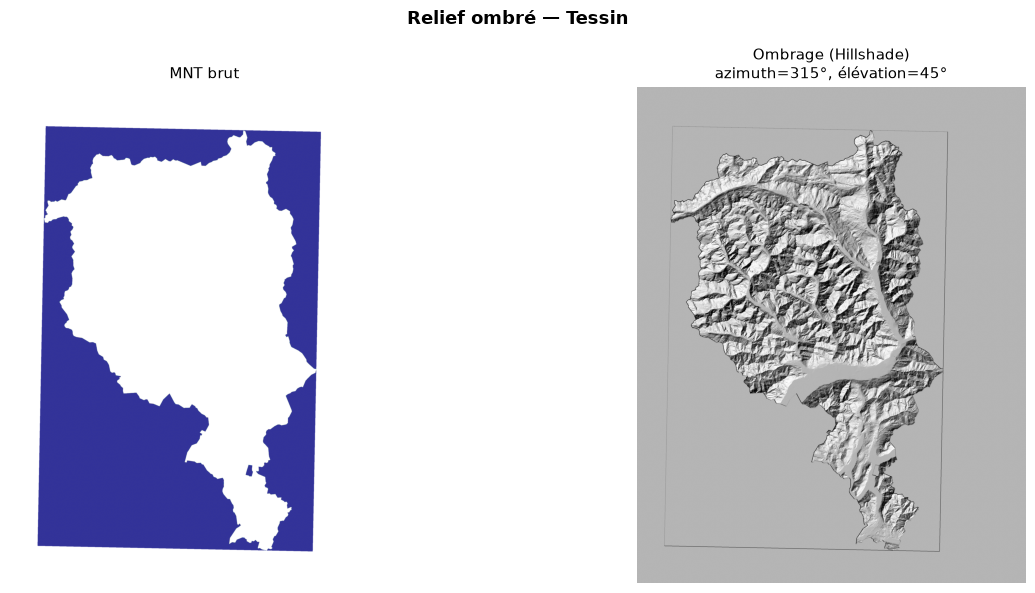

Hillshade sauvegardé : rasters/output/Hillshade_Ticino.tif


In [9]:
def hillshade(dem, res=25, azimuth=315, altitude=45):
    """Calcule l'ombrage depuis un MNT NumPy.
    azimuth  : direction de la lumière (degrés depuis le Nord, sens horaire)
    altitude : angle d'élévation de la source lumineuse (degrés)
    """
    az_rad  = np.radians(360 - azimuth + 90)
    alt_rad = np.radians(altitude)

    dy, dx = np.gradient(dem, res, res)
    slope  = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(-dy, dx)

    hs = (np.sin(alt_rad) * np.cos(slope) +
          np.cos(alt_rad) * np.sin(slope) * np.cos(az_rad - aspect))
    return np.clip(hs, 0, 1)

# Le MNT reprojeté a la résolution de la carte d'occupation du sol (~31 m)
mnt_res = meta_lc['transform'].a   # taille du pixel en x
hs = hillshade(mnt, res=mnt_res)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(mnt, cmap='terrain', origin='upper')
axes[0].set_title('MNT brut', fontsize=11)
axes[0].axis('off')

axes[1].imshow(hs, cmap='gray', vmin=0, vmax=1, origin='upper')
axes[1].set_title('Ombrage (Hillshade)\nazimuth=315°, élévation=45°', fontsize=11)
axes[1].axis('off')

plt.suptitle('Relief ombré — Tessin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Sauvegarde
meta_hs = meta_ref.copy()
meta_hs.update({'dtype': 'float32', 'count': 1})
with rasterio.open('rasters/output/Hillshade_Ticino.tif', 'w', **meta_hs) as dst:
    dst.write(hs.astype(np.float32), 1)
print("Hillshade sauvegardé : rasters/output/Hillshade_Ticino.tif")

---
## Partie 7 — Classification de l'occupation du sol avec RF, XGBoost et MLP

### Contexte et objectif

Les parties précédentes ont produit plusieurs couches raster alignées. On peut maintenant traiter chaque pixel comme une observation et entraîner un modèle de classification — l'une des tâches les plus courantes en télédétection.

| Rôle | Variable | Source |
|---|---|---|
| Cible $y$ | Classe d'occupation du sol (1–6) | `MapTicino1990_8classes.tif` |
| Prédicteurs $x_{1..7}$ | Réflectances Landsat (7 bandes) | Parties 1–3 |
| Prédicteur $x_8$ | Altitude (m) | MNT reprojeté (Partie 4) |

Progression par rapport aux TP précédents :

| TP | Modèles | Nouveauté |
|---|---|---|
| TP02 | Régression OLS | R²/r, IC vs IP, surapprentissage, split entraînement/test |
| TP03 | Polynomiale, GLM, GAM | Non-linéarité, lisseur spatial, K-fold CV, incertitude du R² CV |
| **TP04** | **RF, XGBoost, MLP** | **Modèles non-paramétriques, sélection sur un jeu de validation dédié** |

Les modèles précédents (TP02–TP03) sont tous paramétriques : ils reposent sur une forme mathématique fixée à l'avance (une droite, un polynôme, une somme de splines) dont on estime les paramètres. Random Forest, XGBoost et le **MLP** (*Multi-Layer Perceptron*, un petit réseau de neurones) sont non-paramétriques — leur complexité s'adapte aux données plutôt que d'être fixée par une formule.

Ce qu'on va faire, dans l'ordre :
1. Préparer les données (§7.1) — une matrice de features par pixel (bandes + altitude).
2. Entraîner trois modèles candidats (RF, XGBoost, MLP) et choisir le meilleur sur un jeu de validation dédié, sans jamais regarder le jeu de test avant la toute fin (§7.2).
3. Comparer leurs importances de variables (§7.3).

Comparer plusieurs modèles impose de séparer les données en trois jeux distincts (§7.2) : un pour entraîner, un pour choisir le meilleur, un pour l'évaluation finale.

> ℹ️ **Cible utilisée** : la classification prend comme vérité terrain la carte d'occupation du sol `landcover`, restreinte aux classes 1–6.

### 7.1 Préparation des données — matrice de features par pixel

On reprojette les 7 bandes Landsat sur la grille de l'occupation du sol, puis on construit, pour un sous-échantillon de 20 000 pixels valides, une matrice de 8 features (7 réflectances + altitude) et le vecteur cible (classe 1–6).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
import xgboost as xgb

LC_NAMES  = {1: 'Forêt', 2: 'Prés', 3: 'Eau', 4: 'Neige', 5: 'Sols nus', 6: 'Urbain'}
LC_COLORS = {1: '#2e7d32', 2: '#aed581', 3: '#1565c0', 4: '#e3f2fd', 5: '#bcaaa4', 6: '#e53935'}
BAND_NAMES = ['B1-Bleu', 'B2-Vert', 'B3-Rouge', 'B4-PIR', 'B5-SWIR1', 'B6-Therm', 'B7-SWIR2']

# 1. Rééchantillonner les 7 bandes Landsat sur la grille de l'occupation du sol
print("Rééchantillonnage des 7 bandes Landsat sur la grille de l'occupation du sol...")
bands_on_lc = []
for i, path in enumerate(BAND_FILES):
    band = np.empty((meta_lc['height'], meta_lc['width']), dtype=np.float32)
    with rasterio.open(path) as src:
        reproject(
            source=src.read(1).astype(np.float32),
            destination=band,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=meta_lc['transform'],
            dst_crs=meta_lc['crs'],
            resampling=Resampling.bilinear,
        )
    bands_on_lc.append(band)
    print(f"  {BAND_NAMES[i]:12s} rééchantillonné")

ls_on_lc = np.stack(bands_on_lc, axis=0)   # (7, H, W)
print(f"\nImage rééchantillonnée : {ls_on_lc.shape}  (bandes × lignes × colonnes)")

# 2. Masque : classes valides 1–6, toutes bandes finies et > 0, MNT positif
valid_clf = (
    np.isin(landcover, [1, 2, 3, 4, 5, 6]) &
    np.all(np.isfinite(ls_on_lc) & (ls_on_lc > 0), axis=0) &
    np.isfinite(mnt) & (mnt > 0)
)
print(f"Pixels valides : {valid_clf.sum():,} / {valid_clf.size:,} ({100*valid_clf.mean():.1f} %)")

# 3. Sous-échantillonnage aléatoire : 20 000 pixels
rng = np.random.default_rng(42)
idx_valid_clf = np.argwhere(valid_clf)
chosen = rng.choice(len(idx_valid_clf), 20_000, replace=False)
rows_clf, cols_clf = idx_valid_clf[chosen, 0], idx_valid_clf[chosen, 1]

# 4. Features : 7 bandes + MNT (8 features par pixel)
X_clf = np.column_stack([
    ls_on_lc[:, rows_clf, cols_clf].T,   # (20000, 7)
    mnt[rows_clf, cols_clf],              # (20000,)
])
y_clf = landcover[rows_clf, cols_clf]    # labels 1–6

feat_names_clf = BAND_NAMES + ['MNT']
print(f"\nFeatures ({X_clf.shape[1]}) : {feat_names_clf}")
print(f"Taille du jeu de données : {len(X_clf):,} pixels\n")
print("Distribution des classes :")
for v in sorted(LC_NAMES):
    n = (y_clf == v).sum()
    print(f"  {v} – {LC_NAMES[v]:15s} : {n:5d} pixels ({100*n/len(y_clf):.1f} %)")

Rééchantillonnage des 7 bandes Landsat sur la grille de l'occupation du sol...


  B1-Bleu      rééchantillonné


  B2-Vert      rééchantillonné


  B3-Rouge     rééchantillonné


  B4-PIR       rééchantillonné


  B5-SWIR1     rééchantillonné


  B6-Therm     rééchantillonné


  B7-SWIR2     rééchantillonné

Image rééchantillonnée : (7, 3456, 2707)  (bandes × lignes × colonnes)
Pixels valides : 2,696,468 / 9,355,392 (28.8 %)

Features (8) : ['B1-Bleu', 'B2-Vert', 'B3-Rouge', 'B4-PIR', 'B5-SWIR1', 'B6-Therm', 'B7-SWIR2', 'MNT']
Taille du jeu de données : 20,000 pixels

Distribution des classes :
  1 – Forêt           : 11461 pixels (57.3 %)
  2 – Prés            :  3275 pixels (16.4 %)
  3 – Eau             :   537 pixels (2.7 %)
  4 – Neige           :    83 pixels (0.4 %)
  5 – Sols nus        :  3936 pixels (19.7 %)
  6 – Urbain          :   708 pixels (3.5 %)


### 7.2 Séparation spatiale en trois jeux — entraînement / validation / test

Jusqu'ici (TP02–TP03), un seul modèle était ajusté à la fois : un split entraînement/test (ou une CV) suffisait à estimer sa généralisation. Ici, on compare trois modèles candidats (RF, XGBoost, MLP) : **choisir** le meilleur *et* l'**évaluer** honnêtement sont deux décisions qu'il faut séparer sur des jeux distincts.

| Jeu | Rôle | Part |
|---|---|---|
| **Entraînement** | Ajuster les paramètres de chaque modèle | ≈ 60 % |
| **Validation** | Choisir *lequel* des trois modèles garder (jamais vu pendant l'entraînement) | ≈ 20 % |
| **Test** | Évaluation finale, indépendante de toutes les décisions précédentes | ≈ 20 % |

> ⚠️ Utiliser le jeu de test pour choisir un modèle (« je regarde l'accuracy de test des 3 modèles et je garde le meilleur ») invalide l'évaluation finale : le test n'est alors plus vraiment « jamais vu ». C'est exactement pour éviter ça que le jeu de validation existe.

> 🧭 **Découpage spatial, pas aléatoire.** Les pixels voisins se ressemblent fortement (même parcelle, même versant) : avec un split *aléatoire*, chaque pixel de test aurait presque toujours un voisin quasi identique dans l'entraînement, et l'accuracy **surestimerait** la vraie capacité à cartographier une zone nouvelle — le piège du TP02 §6.7. On découpe donc l'image en **tuiles de 128×128 pixels** et on affecte des tuiles *entières* à chaque jeu (`GroupShuffleSplit` sur l'identifiant de tuile). L'accuracy obtenue reflète alors la prédiction sur des zones réellement non vues. Deux limites à garder en tête : les proportions 60/20/20 sont approximatives (on répartit des tuiles, pas des pixels), et le découpage par blocs empêche de stratifier par classe (une classe rare peut être sous-représentée dans un jeu). Le découpage spatial **réduit** la fuite, il ne l'annule pas : une part d'autocorrélation subsiste à l'intérieur de chaque tuile.

Le **MLP** (`MLPClassifier`), contrairement aux arbres (RF, XGBoost), est sensible à l'échelle des variables : les réflectances Landsat (≈ 0–1) et l'altitude MNT (≈ 0–3000 m) ont des échelles très différentes, ce qui déséquilibre l'apprentissage d'un réseau de neurones. On standardise donc les features (`StandardScaler`) avant le MLP, dans un `Pipeline` — étape inutile, et donc omise, pour RF et XGBoost.


Tuiles : 226 blocs de 128x128 px  |  Entraînement : 11,697   Validation : 4,082   Test : 4,221



Sélection de modèle — précision sur le jeu de validation :
  Random Forest   : 0.879
  XGBoost         : 0.881
  MLP             : 0.882

→ Modèle retenu (validation la plus élevée) : MLP



Accuracy globale / équilibrée sur le test :
  Random Forest   : 0.900 / 0.854
  XGBoost         : 0.900 / 0.879
  MLP             : 0.911 / 0.888


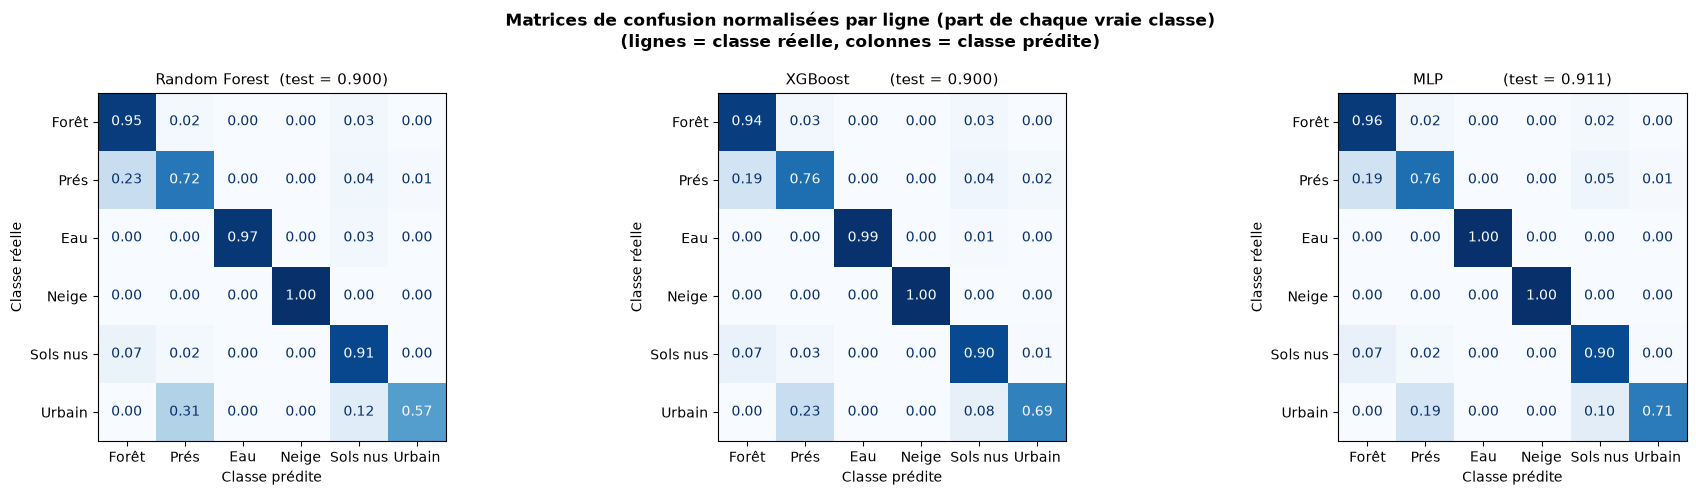

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --- Séparation SPATIALE 60 / 20 / 20 par blocs de pixels (voir §7.2) ---
# On regroupe les pixels en tuiles de 128x128 px et on affecte des tuiles ENTIÈRES à chaque
# jeu : des pixels voisins ne peuvent plus se retrouver à la fois en entraînement et en test.
from sklearn.model_selection import GroupShuffleSplit

BLOCK = 128
block_id = (rows_clf // BLOCK).astype(np.int64) * 100_000 + (cols_clf // BLOCK)

idx_tr, idx_rest = next(GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=42)
                        .split(X_clf, y_clf, groups=block_id))
rel_val, rel_te = next(GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=0)
                       .split(X_clf[idx_rest], y_clf[idx_rest], groups=block_id[idx_rest]))
idx_val, idx_te = idx_rest[rel_val], idx_rest[rel_te]

X_tr, X_val, X_te = X_clf[idx_tr], X_clf[idx_val], X_clf[idx_te]
y_tr, y_val, y_te = y_clf[idx_tr], y_clf[idx_val], y_clf[idx_te]
rows_te, cols_te = rows_clf[idx_te], cols_clf[idx_te]

print(f"Tuiles : {len(np.unique(block_id))} blocs de {BLOCK}x{BLOCK} px  |  "
      f"Entraînement : {len(X_tr):,}   Validation : {len(X_val):,}   Test : {len(X_te):,}")

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

# --- XGBoost (labels obligatoirement 0-indexés en version ≥ 3) ---
le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)                          # 1-6 → 0-5
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss', verbosity=0
).fit(X_tr, y_tr_enc)

# --- MLP : Pipeline avec standardisation (voir §7.2) ---
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
).fit(X_tr, y_tr)

# models[name] = (modèle, encodeur ou None) — l'encodeur ramène XGBoost à l'échelle 1-6
models = {'Random Forest': (rf, None), 'XGBoost': (xgb_clf, le), 'MLP': (mlp, None)}

def predict_labels(name, X):
    model, enc = models[name]
    pred = model.predict(X)
    return enc.inverse_transform(pred) if enc is not None else pred

# --- Sélection de modèle sur le jeu de VALIDATION (jamais utilisé pour l'entraînement) ---
print("\nSélection de modèle — précision sur le jeu de validation :")
val_acc = {}
for name in models:
    val_acc[name] = accuracy_score(y_val, predict_labels(name, X_val))
    print(f"  {name:15s} : {val_acc[name]:.3f}")

best_name = max(val_acc, key=val_acc.get)
print(f"\n→ Modèle retenu (validation la plus élevée) : {best_name}")

# --- Évaluation finale sur le jeu de TEST, pour les trois modèles (comparaison) ---
y_pred_rf  = predict_labels('Random Forest', X_te)
y_pred_xgb = predict_labels('XGBoost', X_te)
y_pred_mlp = predict_labels('MLP', X_te)
acc_rf  = accuracy_score(y_te, y_pred_rf)
acc_xgb = accuracy_score(y_te, y_pred_xgb)
acc_mlp = accuracy_score(y_te, y_pred_mlp)

# Accuracy équilibrée (moyenne des rappels par classe) — plus honnête si les classes sont déséquilibrées
bacc_rf, bacc_xgb, bacc_mlp = (balanced_accuracy_score(y_te, p) for p in (y_pred_rf, y_pred_xgb, y_pred_mlp))
print("\nAccuracy globale / équilibrée sur le test :")
print(f"  {'Random Forest':15s} : {acc_rf:.3f} / {bacc_rf:.3f}")
print(f"  {'XGBoost':15s} : {acc_xgb:.3f} / {bacc_xgb:.3f}")
print(f"  {'MLP':15s} : {acc_mlp:.3f} / {bacc_mlp:.3f}")

class_labels = [LC_NAMES[v] for v in sorted(LC_NAMES)]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, preds, title in [
    (axes[0], y_pred_rf,  f'Random Forest  (test = {acc_rf:.3f})'),
    (axes[1], y_pred_xgb, f'XGBoost        (test = {acc_xgb:.3f})'),
    (axes[2], y_pred_mlp, f'MLP            (test = {acc_mlp:.3f})'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_te, preds, display_labels=class_labels, normalize='true',
        values_format='.2f', cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Classe prédite')
    ax.set_ylabel('Classe réelle')

plt.suptitle("Matrices de confusion normalisées par ligne (part de chaque vraie classe)\n"
             "(lignes = classe réelle, colonnes = classe prédite)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Importances des variables

RF et XGBoost exposent nativement `.feature_importances_` (basé sur la réduction d'impureté apportée par chaque variable dans les arbres). Le MLP n'a pas d'équivalent direct : ses poids sont distribués sur des couches cachées et ne s'interprètent pas variable par variable de la même façon — c'est un des compromis des réseaux de neurones (performance vs interprétabilité directe).

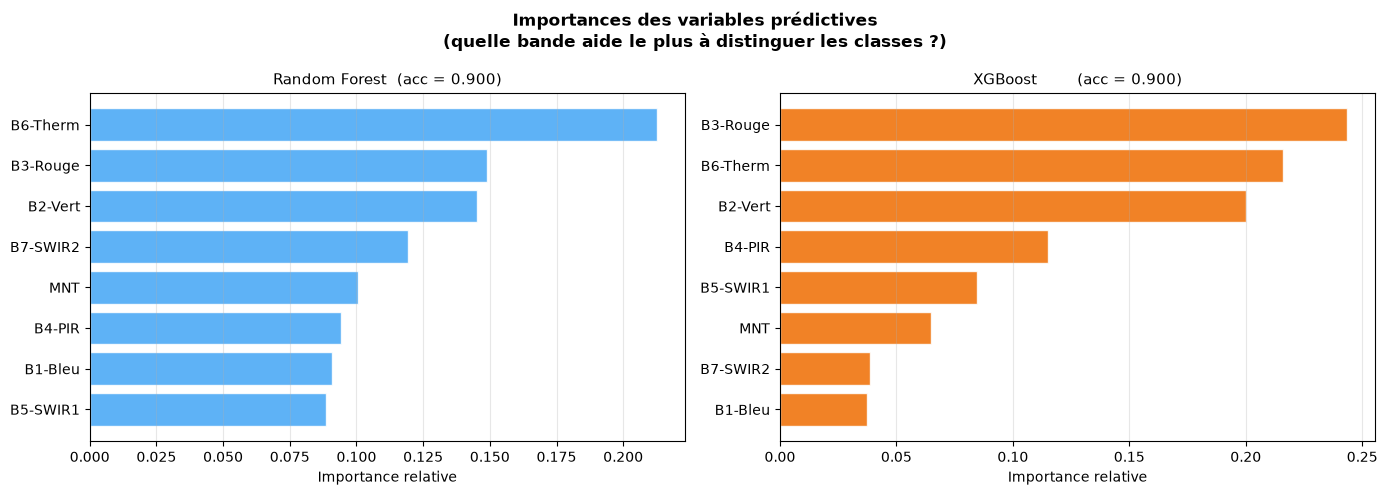

Classement RF — de la plus à la moins importante :
  B6-Therm     : 0.2126
  B3-Rouge     : 0.1490
  B2-Vert      : 0.1450
  B7-SWIR2     : 0.1193


  MNT          : 0.1007
  B4-PIR       : 0.0942
  B1-Bleu      : 0.0908
  B5-SWIR1     : 0.0884


In [12]:
# --- Importances des variables ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, title, color in [
    (axes[0], rf.feature_importances_,      f'Random Forest  (acc = {acc_rf:.3f})',  '#42a5f5'),
    (axes[1], xgb_clf.feature_importances_, f'XGBoost        (acc = {acc_xgb:.3f})', '#ef6c00'),
]:
    order = np.argsort(imp)
    ax.barh(
        [feat_names_clf[i] for i in order], imp[order],
        color=color, alpha=0.85, edgecolor='white'
    )
    ax.set_xlabel('Importance relative')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Importances des variables prédictives\n'
             '(quelle bande aide le plus à distinguer les classes ?)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Classement RF — de la plus à la moins importante :")
for i in np.argsort(rf.feature_importances_)[::-1]:
    print(f"  {feat_names_clf[i]:12s} : {rf.feature_importances_[i]:.4f}")

---
## Récapitulatif

| Opération QGIS | Code Python clé |
|---|---|
| Propriétés de la couche | `rasterio.open(f)` → `.crs`, `.bounds`, `.res`, `.meta` |
| Merge (fusion de bandes) | `np.stack(bands)` + `rasterio.open('w', count=N)` |
| Composition colorée | `np.dstack([r, g, b])` + normalisation percentile |
| Calculatrice raster (NDVI) | `(nir - rouge) / (nir + rouge)` |
| Calculatrice raster (if/and) | `np.where((cond1) & (cond2), val_vrai, val_faux)` |
| Reprojection raster | `rasterio.warp.reproject(src, dst, src_crs=..., dst_crs=...)` |
| Interpolation IDW | `scipy.interpolate.griddata(xy, z, (XX,YY), method='linear')` |
| Ombrage (Hillshade) | `np.gradient(dem)` → calcul slope / aspect / hillshade |
| Écrire un GeoTIFF | `rasterio.open(path, 'w', **meta)` → `.write(array, band)` |

### Partie 7 — Classification ML sur pixels raster

| Étape | Code clé |
|---|---|
| Reprojection bandes Landsat | `rasterio.warp.reproject(src, dst, dst_transform=meta_lc['transform'], ...)` |
| Masque pixels valides | `np.isin(lc, [1..6]) & np.all(ls > 0, axis=0) & (mnt > 0)` |
| Sous-échantillonnage | `np.random.default_rng(42).choice(n_valid, 20_000)` |
| Matrice de features | `np.column_stack([ls_on_lc[:, rows, cols].T, mnt[rows, cols]])` |
| Séparation spatiale 60/20/20 | `GroupShuffleSplit` sur des tuiles de pixels (train / val / test) |
| Random Forest | `RandomForestClassifier(n_estimators=200).fit(X_tr, y_tr)` |
| XGBoost (0-indexé) | `LabelEncoder()` + `XGBClassifier().fit(X_tr, y_tr_enc)` |
| MLP (standardisé) | `make_pipeline(StandardScaler(), MLPClassifier(...)).fit(X_tr, y_tr)` |
| Sélection de modèle | comparer l'accuracy des 3 modèles sur `X_val`, jamais sur `X_te` |
| Matrice de confusion | `ConfusionMatrixDisplay.from_predictions(y_te, y_pred, normalize='true')` |
| Accuracy équilibrée | `balanced_accuracy_score(y_te, y_pred)` (moyenne des rappels par classe) |
| Importances RF / XGBoost | `.feature_importances_` (MLP : pas d'équivalent direct) |

Concepts clés :

| Indicateur | Signification |
|---|---|
| **Précision (accuracy)** | Part des pixels correctement classés ∈ [0, 1] |
| **Accuracy équilibrée** | Moyenne des taux de bonne classification par classe — plus honnête quand les classes sont déséquilibrées |
| **Jeu de validation** | Sert à *choisir* un modèle — jamais à l'entraîner ni à l'évaluer finalement |
| **Matrice de confusion** | Tableau croisé classes réelles × prédites — révèle les confusions fréquentes |
| **Importance des variables** | Contribution de chaque bande/MNT à la qualité de classification (RF, XGBoost) |
| **Autocorrélation spatiale** | Des pixels voisins se ressemblent : un split aléatoire surestime l'accuracy (cf. TP02 §6.7) |

### 🎯 Bonnes pratiques ML — niveau 3 : sélectionner rigoureusement

*(rappel niveaux 1–2 : TP02 posait les fondamentaux — jamais évaluer sur l'entraînement, toujours benchmarker, choisir la bonne métrique, questionner la composition du split ; TP03 a ajouté comparer plusieurs modèles par une procédure commune (CV) et quantifier l'incertitude d'une estimation de performance (CV répétée, bootstrap).)*

| Principe | Où on l'a vu |
|---|---|
| Avec plusieurs modèles candidats, un jeu de validation dédié — distinct du test — sert à choisir lequel garder | §7.2 |
| Ne pas choisir un modèle en regardant le jeu de test : cela invalide l'évaluation finale, même si la tentation est grande | §7.2 |
| Sur des classes déséquilibrées, regarder l'accuracy équilibrée et la matrice de confusion, pas seulement l'accuracy globale | §7.2 |
| Sur données spatialement autocorrélées, un split aléatoire donne une accuracy optimiste — un découpage spatial est plus honnête | §7.2 |
| L'importance des variables aide à interpréter un modèle (quelle bande contribue le plus), mais ne prouve pas une relation causale | §7.3 |

Avec ces trois niveaux, construits progressivement TP après TP, on a les réponses à trois questions que tout projet de modélisation pose — pas seulement la régression ou la classification :

| Question | Outils vus dans ce fil rouge |
|---|---|
| **Quel modèle choisir ?** | Comparer plusieurs candidats sur les mêmes données, avec la même métrique : tableau CV multi-modèles (TP03 §4.7), accuracy de validation (TP04 §7.2). Ne jamais choisir un modèle en regardant le jeu de test. |
| **Comment le valider ?** | Train/test simple (TP02 §6.5) → K-fold CV (TP03 §4.7) → jeu de validation dédié quand plusieurs modèles sont en compétition (TP04 §7.2). Toujours évaluer — et sélectionner — sur des données jamais vues. |
| **Comment quantifier l'incertitude ?** | IC vs IP (TP02 §6.3) → CV répétée et bootstrap (TP03 §4.8–4.9). Un seul chiffre de performance ne dit jamais tout : il faut aussi savoir à quel point il pourrait varier. |

Un point commun à toutes ces réponses : elles demandent de réserver des données qu'on s'interdit d'utiliser avant le bon moment (validation, test). C'est contraignant, mais c'est le prix d'une évaluation qu'on peut réellement croire.

> **Bilan de la progression TP02 → TP04** : d'un modèle unique évalué par split entraînement/test (TP02), à plusieurs modèles non-linéaires comparés par K-fold CV avec attention à l'incertitude d'échantillonnage (TP03), jusqu'à plusieurs modèles non-paramétriques comparés et sélectionnés sur un jeu de validation dédié (TP04) — la rigueur de l'évaluation augmente avec la flexibilité du modèle.


---
## ✅ Validation du TP

Ton notebook est terminé ! Il te reste à valider ce volet Python sur Moodle.

| Activité | Où ? |
|----------|------|
| Questions CodeRunner du TP4 (à soumettre dans Moodle) | [CodeRunner\_TP4]({{ MOODLE_CODERUNNER_TP4 }}) |

> La page d'accueil du TP indique la section Évaluation et rendus (quiz théorique, questions CodeRunner, dépôts) : [retour au TP4](../overview/tp04.md).
